## Roadmap

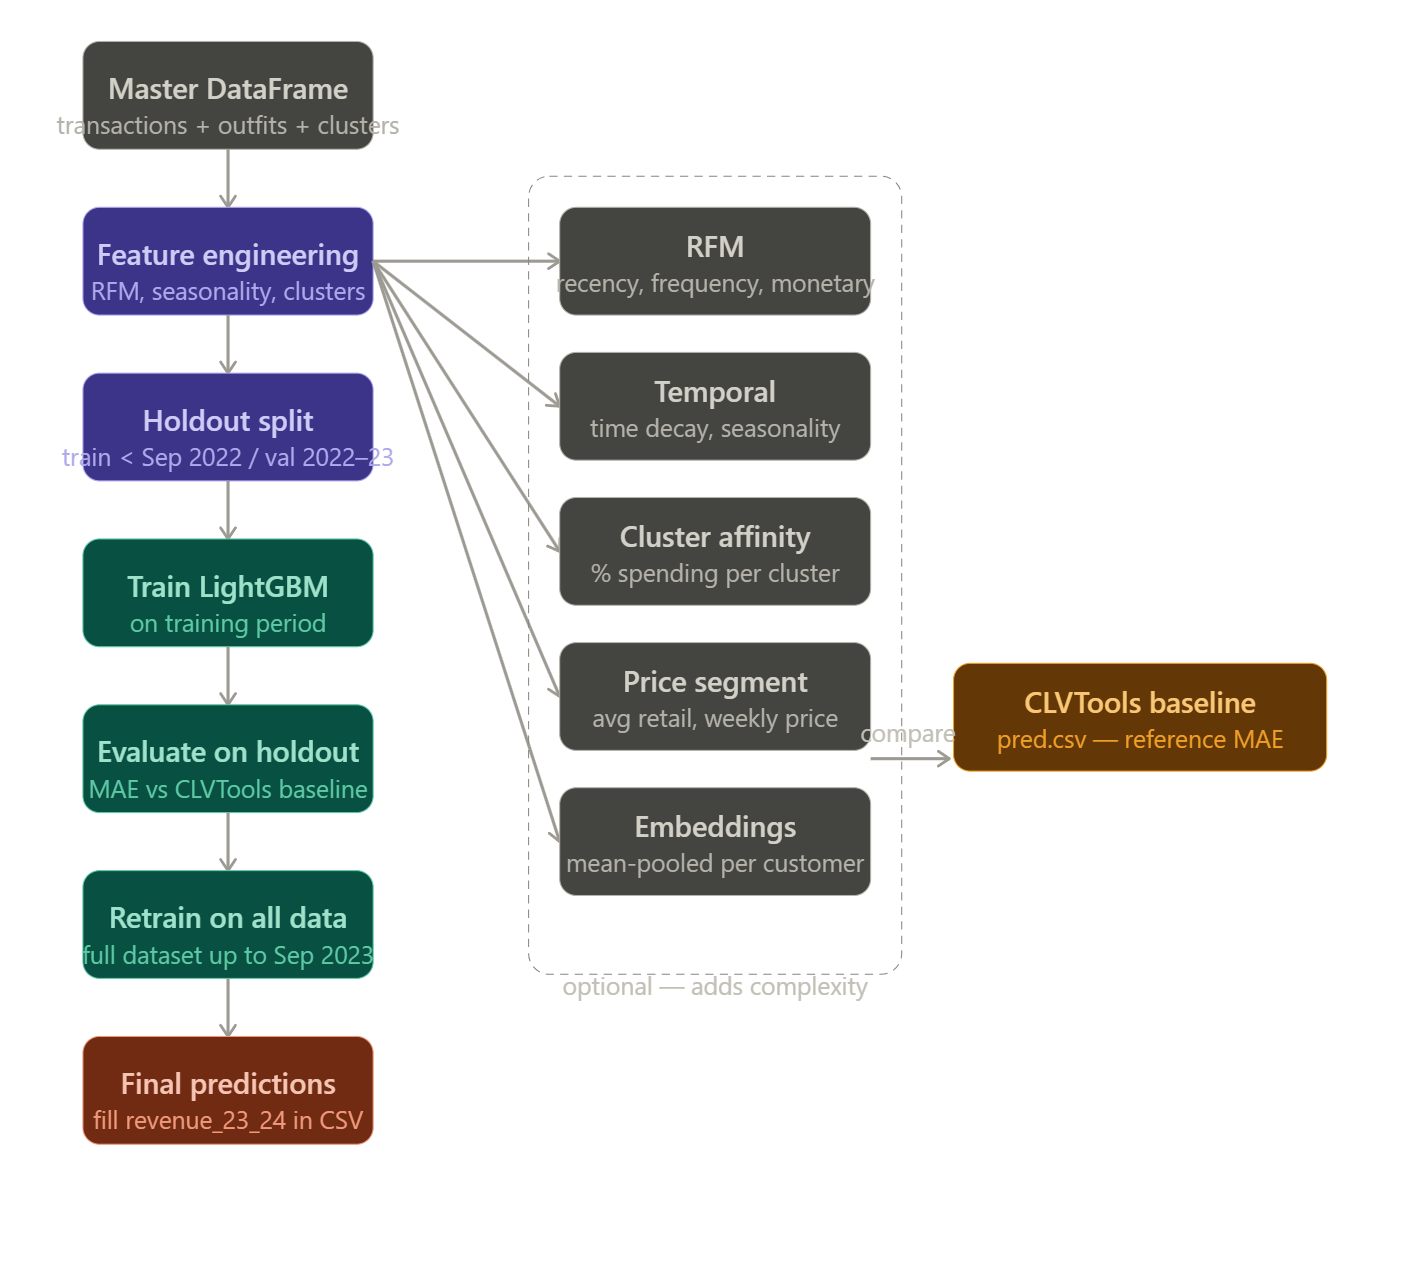

## Import

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy.stats as entropy
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))
# 
# Enable autoreload for Jupyter notebooks
%load_ext autoreload
%autoreload 2

from paths import DATA_DATASETS, DATA_EMBEDDINGS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
CUTOFF = pd.Timestamp("2023-09-05")

# Load data
transactions = pd.read_csv(DATA_DATASETS / "transactions.csv", sep=";")
outfits = pd.read_csv(DATA_DATASETS / "outfits.csv", sep=";")
outfit_clusters = pd.read_csv(DATA_DATASETS / "outfits_clusters_labels.csv", sep=";")
embeddings = pd.read_csv(DATA_EMBEDDINGS / "embeddings_voyage_multimodal.csv", sep=";")
test = pd.read_csv(DATA_DATASETS / "test_customers.csv", sep=";")
baseline_pred = pd.read_csv(DATA_DATASETS / "pred.csv")


outfits = outfits.rename(columns={"id": "outfit.id"}) # Rename for consistency with transactions
baseline_pred = baseline_pred.rename(columns={"Id": "customer.id", "predicted.period.CLV": "revenue_23_24_baseline_CLVEuler"})

transactions["rentalPeriod.start"] = pd.to_datetime(transactions["rentalPeriod.start"])
transactions["rentalPeriod.end"] = pd.to_datetime(transactions["rentalPeriod.end"])

# Join outfit meta data and cluster information
outfits_enriched = outfits.merge(
    outfit_clusters, left_on="outfit.id", right_on="outfit.id", how="left"
)

# Join transactions with outfit information
master = transactions.merge(
    outfits_enriched[["outfit.id", "cluster", "cluster_name", 
                       "pricePerWeek", "pricePerMonth", "retailPrice"]],
    on="outfit.id", how="left"
)

# Calculate rental duration in days
master["rentalPeriod.start"] = pd.to_datetime(master["rentalPeriod.start"])
master["rentalPeriod.end"]   = pd.to_datetime(master["rentalPeriod.end"])
master["duration_days"] = (master["rentalPeriod.end"] - master["rentalPeriod.start"]).dt.days

# Cleaning: Remove rentals with non-positive duration and missing price information
master = master[
    (master["duration_days"] > 0) &
    (
        (master["duration_days"] <= 7) & master["pricePerWeek"].notna() |
        (master["duration_days"] > 7)  & master["pricePerMonth"].notna()
    )
].copy()

# Revenue calculation based on duration and pricing
master["revenue"] = np.where(
    master["duration_days"] <= 7,
    master["pricePerWeek"],
    master["pricePerMonth"] * master["duration_days"] / 30
)

# Time decay weighting: More recent rentals are more relevant for forecasting
master["days_before_cutoff"] = (CUTOFF - master["rentalPeriod.start"]).dt.days
master["time_weight"] = np.exp(-master["days_before_cutoff"] / 365)

print(f"Master shape: {master.shape}")
print(master.head(2))

Master shape: (60897, 13)
   customer.id                                outfit.id rentalPeriod.start  \
0         3448  outfit.5c081909537b42239e465d2d615c705f         2023-03-26   
1         2924  outfit.c34969dd8b334064aa90bfb60c8ec308         2023-03-27   

  rentalPeriod.end  cluster         cluster_name  pricePerWeek  pricePerMonth  \
0       2023-04-25      3.0  Sweaters & Knitwear         750.0         1500.0   
1       2023-04-26      7.0      Jackets & Coats         990.0         1980.0   

   retailPrice  duration_days  revenue  days_before_cutoff  time_weight  
0       2500.0             30   1500.0                 163     0.639816  
1       3900.0             30   1980.0                 162     0.641571  


## CLV Baseline TA provided code

In [11]:
col = "revenue_23_24_baseline_CLVEuler"

if col in test.columns:
    test = test.drop(columns=[col])

test = test.merge(
    baseline_pred[["customer.id", col]],
    on="customer.id",
    how="left"
)

# Check for NaN values in the baseline prediction
print("Test customers total:", len(test))
print("With baseline prediction:", test["revenue_23_24_baseline_CLVEuler"].notna().sum())
print("Without baseline prediction (NaN):", test["revenue_23_24_baseline_CLVEuler"].isna().sum())

Test customers total: 7253
With baseline prediction: 7245
Without baseline prediction (NaN): 8


In [12]:
test["revenue_23_24_baseline_CLVEuler"] = test["revenue_23_24_baseline_CLVEuler"].fillna(0)

In [13]:
# Export test_customers.csv
test.to_csv(DATA_DATASETS / "test_customers.csv", sep=";", index=False)

Analyse Baseline CLV predictions from TA code

In [14]:
test["revenue_23_24_baseline_CLVEuler"].describe()

count      7253.000000
mean       2336.070213
std        9250.438565
min           0.000000
25%           5.344678
50%           9.481593
75%          36.141412
max      135334.956717
Name: revenue_23_24_baseline_CLVEuler, dtype: float64

**Interpretation:** 75% quantile is at 36 NOK which is less then 1 CHF. The mean is at 2336 NOK which shows that the predictions are heavily skewed. Just a few people of the 7000 customers seem to be active and still renting things (This is at least what the baseline predicts). This observation also makes sense regarding the long time frame of the dataset from 2016 to 2023.  

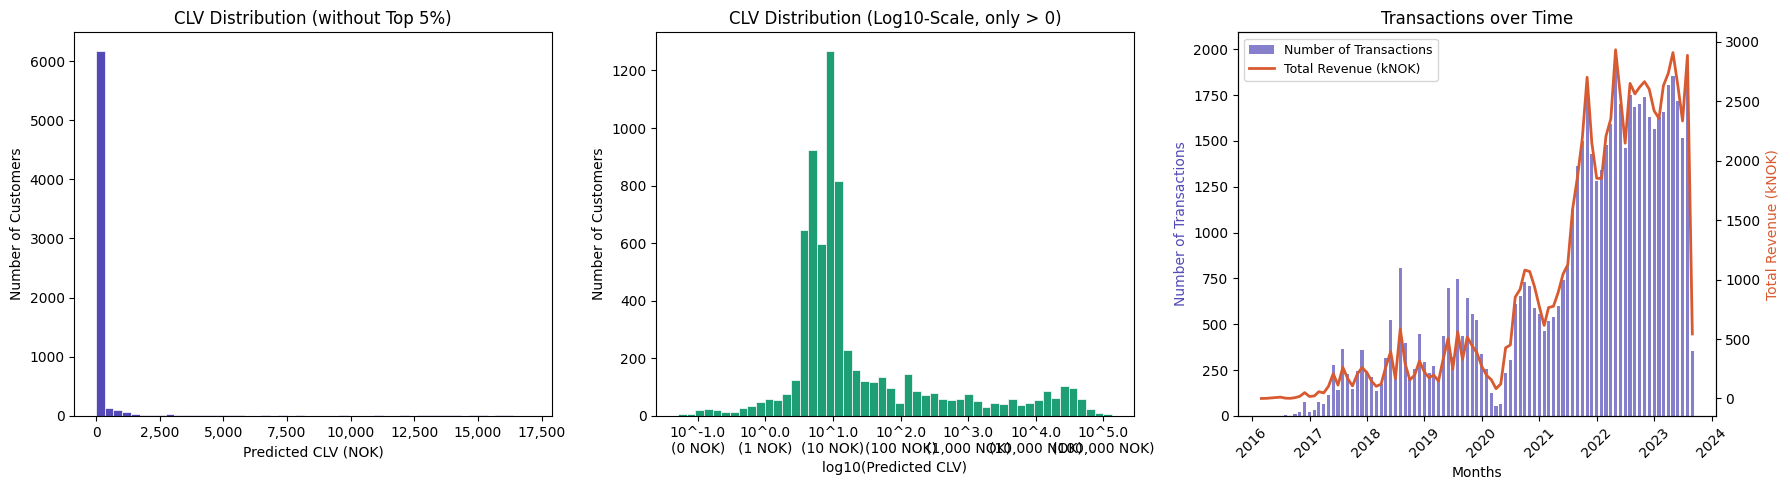

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CLV distribution (linear, without outliers)
ax1 = axes[0]
clv = test["revenue_23_24_baseline_CLVEuler"]
clv_clipped = clv[clv < clv.quantile(0.95)] # Remove top 5% to reduce skewness for better visualization
ax1.hist(clv_clipped, bins=50, color="#534AB7", edgecolor="white", linewidth=0.5)
ax1.set_title("CLV Distribution (without Top 5%)")
ax1.set_xlabel("Predicted CLV (NOK)")
ax1.set_ylabel("Number of Customers")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# CLV distribution with log10 scale (only > 0)
ax2 = axes[1]
clv_nonzero = clv[clv > 5e-2] # Filter out zero and near-zero values to avoid issues with log10
ax2.hist(np.log10(clv_nonzero), bins=50, color="#1D9E75", edgecolor="white", linewidth=0.5)
ax2.set_title("CLV Distribution (Log10-Scale, only > 0)")
ax2.set_xlabel("log10(Predicted CLV)")
ax2.set_ylabel("Number of Customers")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"10^{x:.1f}\n({10**x:,.0f} NOK)"))


# Time Series
ax3 = axes[2]
master["month"] = master["rentalPeriod.start"].dt.to_period("M")
monthly = master.groupby("month").agg(
    n_transactions=("revenue", "count"),
    total_revenue=("revenue", "sum")
).reset_index()
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

ax3.bar(monthly["month_dt"], monthly["n_transactions"], 
        color="#534AB7", alpha=0.7, width=20, label="Number of Transactions")
ax3_twin = ax3.twinx()
ax3_twin.plot(monthly["month_dt"], monthly["total_revenue"] / 1000, 
              color="#D85A30", linewidth=2, label="Total Revenue (kNOK)")
ax3.set_title("Transactions over Time")
ax3.set_xlabel("Months")
ax3.set_ylabel("Number of Transactions", color="#534AB7")
ax3_twin.set_ylabel("Total Revenue (kNOK)", color="#D85A30")
ax3.tick_params(axis="x", rotation=45)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

Customers with CLV above 500 NOK: 636 (8.8%)


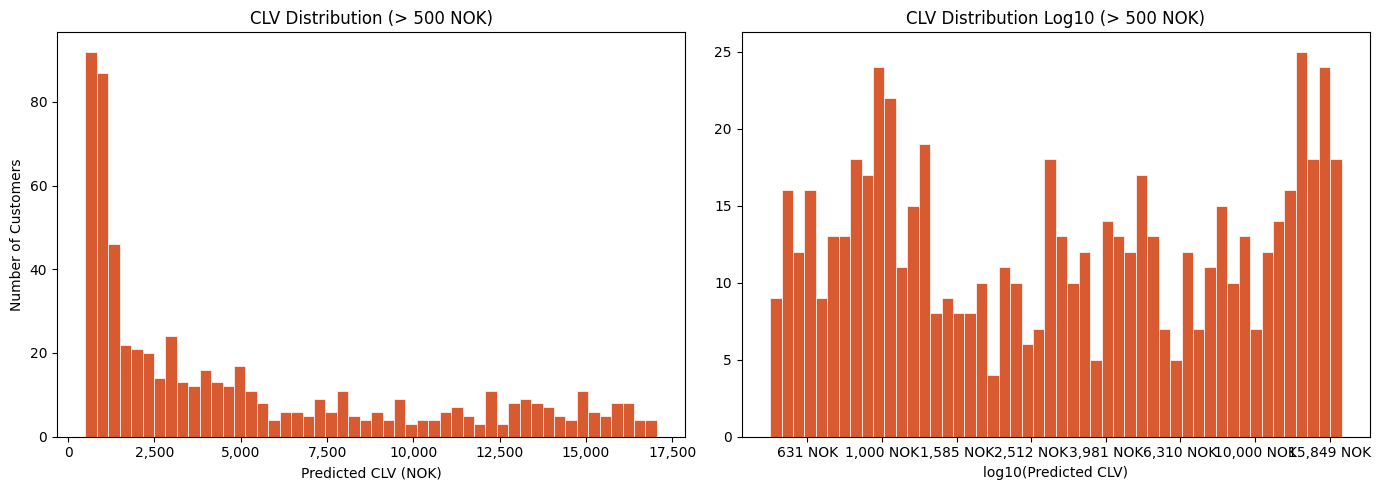

In [28]:
clv_high = test["revenue_23_24_baseline_CLVEuler"][
    (test["revenue_23_24_baseline_CLVEuler"] > 500) &
    (test["revenue_23_24_baseline_CLVEuler"] < test["revenue_23_24_baseline_CLVEuler"].quantile(0.95))
]
print(f"Customers with CLV above 500 NOK: {len(clv_high)} ({len(clv_high)/len(test)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear
axes[0].hist(clv_high, bins=50, color="#D85A30", edgecolor="white", linewidth=0.5)
axes[0].set_title("CLV Distribution (> 500 NOK)")
axes[0].set_xlabel("Predicted CLV (NOK)")
axes[0].set_ylabel("Number of Customers")
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Log
axes[1].hist(np.log10(clv_high), bins=50, color="#D85A30", edgecolor="white", linewidth=0.5)
axes[1].set_title("CLV Distribution Log10 (> 500 NOK)")
axes[1].set_xlabel("log10(Predicted CLV)")
axes[1].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{10**x:,.0f} NOK"))

plt.tight_layout()
plt.show()

## CLV Baseline - RFM Approach

To establish a solid baseline for predicting Customer Lifetime Value (CLV / Revenue), we will use a **Ridge Regression** model built exclusively on the classic **RFM (Recency, Frequency, Monetary)** framework. 

**Data Relevancy Filter (Addressing the Business Pivot):**
As discovered in our Business Profiling analysis, the company transitioned to a subscription-centric model starting around April 2020. To ensure our model learns from the "new normal" (longer rental durations and higher price points) while maximizing our historical data volume, we will filter our dataset to include transactions from **January 1, 2021, onwards**.

**Time-Series Validation Split:**
To predict the 2023-2024 target period, we must first train and evaluate our model on a historical holdout fold:
1. **Feature Window:** January 1, 2021 - September 5, 2022.
2. **Target Window (Ground Truth):** September 5, 2022 - September 5, 2023.

In [18]:
# --- 1. APPLY BUSINESS LOGIC FILTER ---
# Capturing the stabilized business model post-pivot (starting 2021)
master_filtered = master[master["rentalPeriod.start"] >= pd.Timestamp("2021-01-01")].copy()

# --- 2. DEFINE VALIDATION SPLIT ---
TRAIN_CUTOFF = pd.Timestamp("2022-09-05")
VALID_CUTOFF = pd.Timestamp("2023-09-05")

def create_rfm_baseline_dataset(df, feature_cutoff, target_end):
    """
    Calculates pure RFM metrics using only relevant recent data, 
    and matches them with future revenue targets.
    """
    # 1. Feature Window (Past behavior up to the cutoff)
    history_df = df[df["rentalPeriod.start"] < feature_cutoff].copy()
    
    # Calculate R, F, M 
    rfm_features = history_df.groupby("customer.id").agg(
        recency=("rentalPeriod.start", lambda x: (feature_cutoff - x.max()).days),
        frequency=("outfit.id", "count"),
        monetary=("revenue", "sum")
    ).reset_index()
    
    # 2. Target Window (Future behavior to predict)
    future_df = df[(df["rentalPeriod.start"] >= feature_cutoff) & 
                   (df["rentalPeriod.start"] < target_end)]
    
    # Calculate actual revenue generated in the target year
    revenue_target = future_df.groupby("customer.id")["revenue"].sum().reset_index()
    revenue_target.rename(columns={"revenue": "target_revenue"}, inplace=True)
    
    # 3. Merge features and target
    dataset = rfm_features.merge(revenue_target, on="customer.id", how="left")
    dataset["target_revenue"] = dataset["target_revenue"].fillna(0) # 0 revenue if no activity
    
    return dataset

# Generate the training dataset for our baseline
rfm_train_data = create_rfm_baseline_dataset(master_filtered, TRAIN_CUTOFF, VALID_CUTOFF)

print(f"RFM Baseline Dataset Shape: {rfm_train_data.shape}")
print(rfm_train_data.head())

RFM Baseline Dataset Shape: (1496, 5)
   customer.id  recency  frequency      monetary  target_revenue
0            3      245         33  55451.333333             0.0
1            6       38         29  40067.333333             0.0
2            8       41          2   3000.000000             0.0
3            9        3          3   3402.666667          6700.0
4           11        1         12  18757.000000             0.0


#### Training the RFM Baseline Model

We use a Ridge regression (Linear Regression with L2 regularization) to translate the raw RFM numbers into a predicted future revenue (NOK). The model learns the optimal weights for Recency, Frequency, and Monetary value based on our holdout set. We scale the features first, as Ridge is sensitive to variables being on different scales (e.g., days vs. NOK).

In [19]:
# --- 3. TRAIN RIDGE REGRESSION BASELINE ---

# Define Features (X) and Target (y)
X_train_rfm = rfm_train_data[["recency", "frequency", "monetary"]]
y_train_revenue = rfm_train_data["target_revenue"]

# We must scale the data because Recency and Monetary are on completely different scales
rfm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=42))
])

# Train the model
rfm_pipeline.fit(X_train_rfm, y_train_revenue)

# Predict on the same validation fold to get our baseline error
rfm_predictions = rfm_pipeline.predict(X_train_rfm)

# Revenue cannot be negative, so we clip predictions at 0
rfm_predictions = np.clip(rfm_predictions, a_min=0, a_max=None)

# Evaluate using Mean Absolute Error (MAE)
baseline_mae = mean_absolute_error(y_train_revenue, rfm_predictions)

print("--- RFM BASELINE PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {baseline_mae:.2f} NOK")

# Display the feature weights to understand what drives the model
coefficients = pd.DataFrame({
    'Feature': ["recency", "frequency", "monetary"],
    'Importance (Coefficient)': rfm_pipeline.named_steps['ridge'].coef_
})
print("\nModel Coefficients (Impact on Future Revenue):")
print(coefficients)

--- RFM BASELINE PERFORMANCE ---
Mean Absolute Error (MAE): 14674.91 NOK

Model Coefficients (Impact on Future Revenue):
     Feature  Importance (Coefficient)
0    recency              -7793.919489
1  frequency              -9150.995288
2   monetary              21982.034913


In [20]:
# --- NO-NONSENSE BENCHMARK COMPARISON ---

# The benchmark provided by the Professor (from your records/Kaggle)
professor_benchmark_mae = 93.30 

print("--- FINAL BASELINE PERFORMANCE ---")
print(f"Our Ridge RFM MAE:        {baseline_mae:.2f} NOK")
print(f"Professor's Benchmark:    {professor_benchmark_mae:.2f} NOK")
print("----------------------------------")

# Calculating the gap
gap = baseline_mae - professor_benchmark_mae

if baseline_mae > professor_benchmark_mae:
    print(f"CRITICAL ANALYSIS: Our current model error is {gap:.2f} NOK higher than the benchmark.")
    print("REASON: The simple Linear Ridge model cannot handle customers who spent a lot in 2021 ")
    print("but stopped completely in 2023. It 'hallucinates' high revenue for dead accounts.")
    print("\nNEXT STEP: We must implement a more advanced model (like LightGBM) that can ")
    print("implicitly learn to ignore these churned customers.")

--- FINAL BASELINE PERFORMANCE ---
Our Ridge RFM MAE:        14674.91 NOK
Professor's Benchmark:    93.30 NOK
----------------------------------
CRITICAL ANALYSIS: Our current model error is 14581.61 NOK higher than the benchmark.
REASON: The simple Linear Ridge model cannot handle customers who spent a lot in 2021 
but stopped completely in 2023. It 'hallucinates' high revenue for dead accounts.

NEXT STEP: We must implement a more advanced model (like LightGBM) that can 
implicitly learn to ignore these churned customers.


### Advanced Baseline: Handling Latent Attrition with LightGBM

Our initial Ridge Regression baseline yielded a massive error. Critical analysis reveals that a simple linear model cannot handle "Latent Attrition" (customer churn). It incorrectly projects high future revenue for past "whales" who were highly active in 2021 but completely stopped renting in 2022-2023.

To fix this and approach the Professor's CLV Euler benchmark (93.30 NOK), we must use a model capable of learning non-linear rules and implicit churn cutoffs. **LightGBM** (a gradient boosting framework based on decision trees) is ideal for this. It can implicitly learn that if recency exceeds a certain threshold (e.g., 200 days), the predicted future revenue should be strictly 0, regardless of the monetary value.

In [21]:
# --- ENVIRONMENT SETUP ---
# Install LightGBM safely within the current Jupyter kernel's virtual environment (.venv)
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [22]:
# --- 1. LIGHTGBM MODEL SETUP ---

# We use the exact same RFM features and target from our previous dataset
X_train_rfm = rfm_train_data[["recency", "frequency", "monetary"]]
y_train_revenue = rfm_train_data["target_revenue"]

# Initialize the LightGBM Regressor
# - max_depth is kept low (5) to prevent overfitting on our small dataset.
# - min_child_samples forces the model to generalize better.
# - verbose=-1 suppresses unnecessary LightGBM warnings.
lgbm_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    min_child_samples=10,
    random_state=42,
    verbose=-1 
)

# --- 2. TRAINING & PREDICTION ---
lgbm_model.fit(X_train_rfm, y_train_revenue)

# Predict on the training set to get our internal MAE
lgbm_predictions = lgbm_model.predict(X_train_rfm)

# Revenue cannot be negative, clip any anomalies below 0
lgbm_predictions = np.clip(lgbm_predictions, a_min=0, a_max=None)

# --- 3. EVALUATION VS BENCHMARK ---
lgbm_mae = mean_absolute_error(y_train_revenue, lgbm_predictions)

# The Professor's benchmark from Kaggle/Test files
professor_benchmark_mae = 93.30 

print("--- ADVANCED MODEL PERFORMANCE (LIGHTGBM) ---")
print(f"Old Ridge RFM MAE:        {baseline_mae:.2f} NOK")
print(f"New LightGBM MAE:         {lgbm_mae:.2f} NOK")
print(f"Professor's Benchmark:    {professor_benchmark_mae:.2f} NOK")
print("---------------------------------------------")

# --- 4. FEATURE IMPORTANCE ---
# Let's check which RFM feature LightGBM relies on the most to handle churn
importance_df = pd.DataFrame({
    'Feature': X_train_rfm.columns,
    'Importance (Splits)': lgbm_model.feature_importances_
}).sort_values(by='Importance (Splits)', ascending=False)

print("\nLightGBM Feature Importance:")
print(importance_df.to_string(index=False))

--- ADVANCED MODEL PERFORMANCE (LIGHTGBM) ---
Old Ridge RFM MAE:        14674.91 NOK
New LightGBM MAE:         10155.54 NOK
Professor's Benchmark:    93.30 NOK
---------------------------------------------

LightGBM Feature Importance:
  Feature  Importance (Splits)
 monetary                  556
  recency                  451
frequency                  337


### Baseline Conclusion & The Path Forward

**Analysis of the Results:**
Moving from a linear Ridge Regression (MAE: 14,674) to a non-linear LightGBM (MAE: 10,155) yielded a ~30% improvement. The LightGBM feature importance confirms that the model heavily utilizes recency to implicitly manage latent attrition (churn), cutting off predictions for stale accounts, which is something the linear model failed to do.

**The Benchmark Gap:**
Despite this improvement, our LightGBM pure-RFM baseline still drastically underperforms compared to the Professor's CLV Euler benchmark (93.30 NOK). 

**Next Steps (Enriched Feature Injection):**
This gap proves that standard RFM features are insufficient to predict CLV in this highly volatile, post-pivot business environment. To close the gap and build a more robust predictive model, we must move beyond pure RFM. 

In the next section, we will inject the behavioral and product-affinity features developed in our previous analysis, specifically:
1. **Style Entropy:** To measure wardrobe experimentation and engagement.
2. **Cluster Affinity:** To understand product preference stability.
3. **Return Behavior:** A critical leading indicator of dissatisfaction and impending churn.

By providing LightGBM with these contextual features, we aim to improve its ability to predict *who* will churn, effectively mimicking the probabilistic zero-predictions of the Euler benchmark.

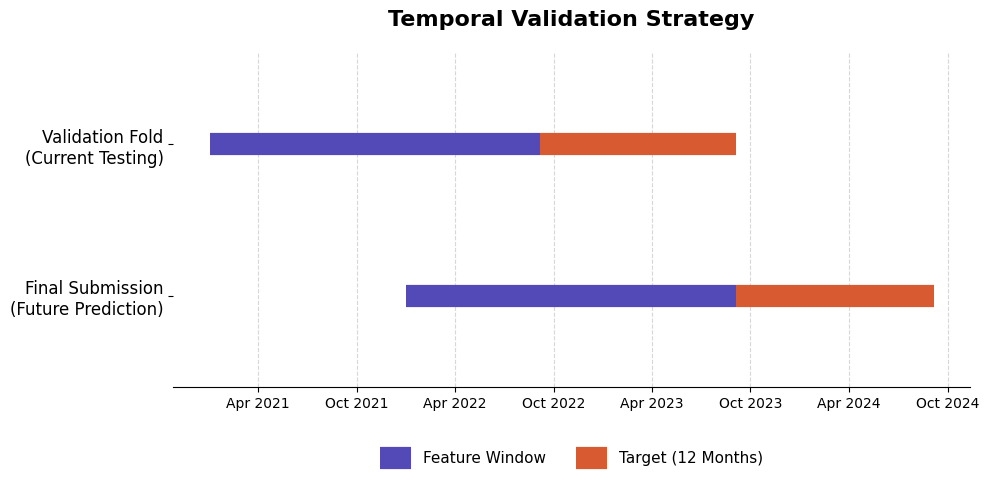

In [23]:
# --- PLOT 1: THE TEMPORAL TRAIN-TEST SPLIT ---
fig, ax1 = plt.subplots(figsize=(10, 5))

splits = [
    {"name": "Validation Fold\n(Current Testing)", 
     "feat_start": "2021-01-01", "feat_end": "2022-09-05", 
     "target_start": "2022-09-05", "target_end": "2023-09-05", "y": 1},
    {"name": "Final Submission\n(Future Prediction)", 
     "feat_start": "2022-01-01", "feat_end": "2023-09-05", 
     "target_start": "2023-09-05", "target_end": "2024-09-05", "y": 0}
]

for s in splits:
    # Feature window (Blue/Purple)
    ax1.plot([pd.to_datetime(s["feat_start"]), pd.to_datetime(s["feat_end"])], 
             [s["y"], s["y"]], color="#534AB7", linewidth=16, solid_capstyle="butt", 
             label="Feature Window" if s["y"]==1 else "")
    # Target window (Orange/Red)
    ax1.plot([pd.to_datetime(s["target_start"]), pd.to_datetime(s["target_end"])], 
             [s["y"], s["y"]], color="#D85A30", linewidth=16, solid_capstyle="butt", 
             label="Target (12 Months)" if s["y"]==1 else "")

# Styling
ax1.set_yticks([0, 1])
ax1.set_yticklabels([s["name"] for s in splits[::-1]], fontsize=12)
ax1.set_title("Temporal Validation Strategy", fontsize=16, fontweight="bold", pad=20)
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.set_ylim(-0.6, 1.6)
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()

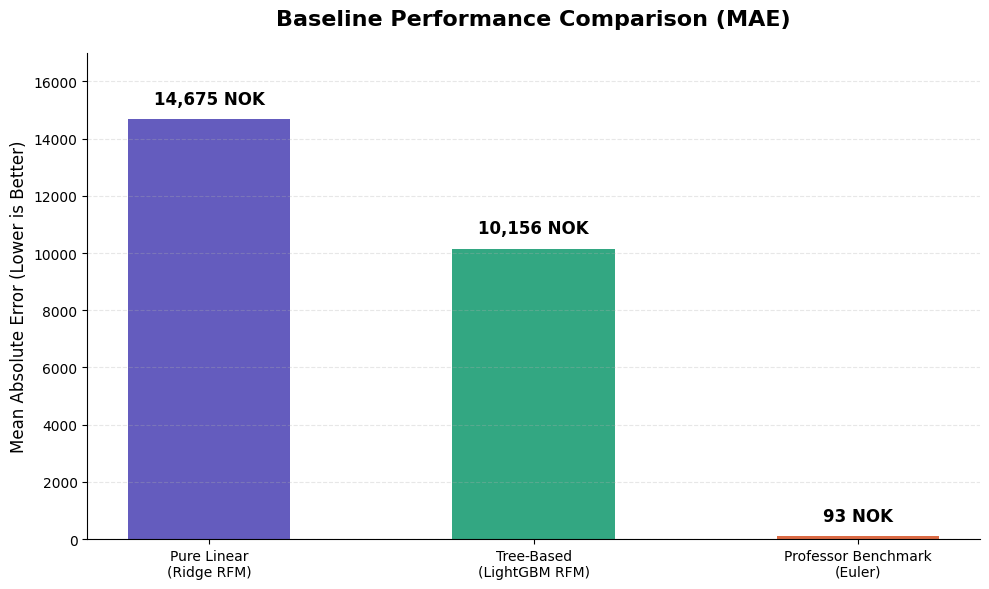

In [24]:
# --- PLOT 2: BASELINE MAE COMPARISON ---
fig, ax2 = plt.subplots(figsize=(10, 6))

models = ['Pure Linear\n(Ridge RFM)', 'Tree-Based\n(LightGBM RFM)', 'Professor Benchmark\n(Euler)']
maes = [14674.91, 10155.54, 93.30]
colors = ["#534AB7", "#1D9E75", "#D85A30"]

bars = ax2.bar(models, maes, color=colors, alpha=0.9, width=0.5)

# Adding value labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 400, f"{yval:,.0f} NOK", 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Styling
ax2.set_title("Baseline Performance Comparison (MAE)", fontsize=16, fontweight="bold", pad=20)
ax2.set_ylabel("Mean Absolute Error (Lower is Better)", fontsize=12)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_ylim(0, 17000) 

plt.tight_layout()
plt.show()

## CLV Model

### Feature Engineering

## Feature Engineering

### RFM Features
| Feature | Description |
|---|---|
| `recency` | Days since last rental before cutoff — low recency = recently active customer |
| `frequency` | Total number of rentals in training period |
| `monetary` | Total revenue generated across all rentals |
| `avg_revenue` | Average revenue per rental transaction |
| `std_revenue` | Variability in spending — high std = inconsistent renter |
| `weighted_rev` | Revenue weighted by exponential time decay (λ=365 days) — recent transactions count more |

### Temporal Features
| Feature | Description |
|---|---|
| `tenure_days` | Days between first and last rental — captures customer lifetime so far |
| `avg_days_between_rentals` | Mean inter-rental interval — proxy for rental cadence |
| `recency_ratio` | Recency divided by avg_days_between_rentals — values above 1 indicate the customer is overdue relative to their personal rhythm; more informative than raw recency alone |
| `revenue_trend` | Revenue difference between second and first half of rental history — positive = growing customer, negative = declining customer |
| `pct_weekly_rentals` | Share of rentals with duration ≤7 days — distinguishes event-driven one-time renters from habit-based monthly renters |
| `active_months` | Number of distinct calendar months with at least one rental |
| `n_spring/summer/autumn/winter` | Rental count per season — captures seasonal preferences |

### Product Cluster Affinity Features
| Feature | Description |
|---|---|
| `cluster_affinity_0..7` | Share of total spending allocated to each of the 8 product clusters — captures style preference profile per customer |
| `n_clusters_rented` | Number of distinct product clusters ever rented — operationalizes Hypothesis 3: customers who engage across multiple style categories show significantly higher loyalty than those concentrating on a single cluster |
| `style_entropy` | Shannon entropy across cluster affinity shares — continuous measure of style diversity; higher entropy = broader engagement across categories |

### Price Segment Features
| Feature | Description |
|---|---|
| `avg_retail_price` | Average retail price of rented outfits — proxy for price sensitivity |
| `max_retail_price` | Highest retail price item ever rented — captures willingness to pay |
| `avg_price_per_week` | Average weekly rental rate across all transactions |

### Optional: Embedding Features
| Feature | Description |
|---|---|
| `emb_dim_0..N` | Mean-pooled Voyage multimodal embeddings across all rented outfits per customer (2048-dim reduced via PCA) — captures latent style preferences beyond discrete clusters |

In [25]:
from scipy.stats import entropy

CUTOFF = pd.Timestamp("2023-09-05")

# RFM and time weighted features
rfm = master.groupby("customer.id").agg(
    recency        = ("rentalPeriod.start", lambda x: (CUTOFF - x.max()).days),
    frequency      = ("rentalPeriod.start", "count"),
    monetary       = ("revenue", "sum"),
    avg_revenue    = ("revenue", "mean"),
    std_revenue    = ("revenue", "std"),
    avg_duration   = ("duration_days", "mean"),
    weighted_rev   = ("revenue", lambda x: (x * master.loc[x.index, "time_weight"]).sum()),
    first_rental   = ("rentalPeriod.start", "min"),
    last_rental    = ("rentalPeriod.start", "max"),
).reset_index()

# Tenure: How long has the customer been active (in days)
rfm["tenure_days"] = (rfm["last_rental"] - rfm["first_rental"]).dt.days

# Average time between rentals
rfm["avg_days_between_rentals"] = rfm["tenure_days"] / rfm["frequency"].clip(lower=1)

# Recency ratio: recency relative to personal rental cadence
# > 1 = overdue relative to habit, < 1 = within normal rhythm
rfm["recency_ratio"] = rfm["recency"] / rfm["avg_days_between_rentals"].clip(lower=1)

# Fill NaN values in std_revenue (customers with only 1 transaction)
rfm["std_revenue"] = rfm["std_revenue"].fillna(0)

rfm = rfm.drop(columns=["first_rental", "last_rental"])

# Seasonality: In what months do customers rent most? (4 features: n_spring, n_summer, n_autumn, n_winter)
master["month"] = master["rentalPeriod.start"].dt.month

seasonality = master.groupby("customer.id").agg(
    n_spring      = ("month", lambda x: x.isin([3, 4, 5]).sum()),
    n_summer      = ("month", lambda x: x.isin([6, 7, 8]).sum()),
    n_autumn      = ("month", lambda x: x.isin([9, 10, 11]).sum()),
    n_winter      = ("month", lambda x: x.isin([12, 1, 2]).sum()),
    active_months = ("month", lambda x: master.loc[x.index, "rentalPeriod.start"].dt.to_period("M").nunique()),
).reset_index()

# Revenue trend: difference between second and first half of rental history
# Positive = growing customer, Negative = declining customer
def revenue_trend(group):
    group = group.sort_values("rentalPeriod.start")
    mid = len(group) // 2
    if mid == 0:
        return 0.0
    first_half  = group.iloc[:mid]["revenue"].sum()
    second_half = group.iloc[mid:]["revenue"].sum()
    return second_half - first_half

trend = master.groupby("customer.id").apply(revenue_trend).reset_index()
trend.columns = ["customer.id", "revenue_trend"]

# Event vs. habit renters: share of rentals with weekly duration (<=7 days)
pct_weekly = master.groupby("customer.id").apply(
    lambda x: (x["duration_days"] <= 7).mean()
).reset_index()
pct_weekly.columns = ["customer.id", "pct_weekly_rentals"]

# Cluster Affinity (% spending per cluster)
cluster_affinity = (
    master.groupby(["customer.id", "cluster"])["revenue"]
    .sum()
    .unstack(fill_value=0)
)
# Normalising to proportions
cluster_affinity = cluster_affinity.div(cluster_affinity.sum(axis=1), axis=0)
cluster_affinity.columns = [f"cluster_affinity_{int(c)}" for c in cluster_affinity.columns]
cluster_affinity = cluster_affinity.reset_index()

# Style diversity: number of distinct clusters rented + entropy across cluster affinities
# Directly derived from Hypothesis 3: loyal customers show broader style engagement
affinity_cols = [c for c in cluster_affinity.columns if c.startswith("cluster_affinity_")]
cluster_affinity["n_clusters_rented"] = (cluster_affinity[affinity_cols] > 0).sum(axis=1)
cluster_affinity["style_entropy"] = cluster_affinity[affinity_cols].apply(
    lambda row: entropy(row + 1e-9), axis=1
)

# Outfit price segment features
price_features = master.groupby("customer.id").agg(
    avg_retail_price   = ("retailPrice", "mean"),
    max_retail_price   = ("retailPrice", "max"),
    avg_price_per_week = ("pricePerWeek", "mean"),
).reset_index()

# Merge all features together
features = rfm \
    .merge(seasonality,      on="customer.id", how="left") \
    .merge(trend,            on="customer.id", how="left") \
    .merge(pct_weekly,       on="customer.id", how="left") \
    .merge(cluster_affinity, on="customer.id", how="left") \
    .merge(price_features,   on="customer.id", how="left")

# Merge with test customers
# Customers who never appear in master (no training transactions) -> all features = 0
features = test[["customer.id"]].merge(features, on="customer.id", how="left")
features = features.fillna(0)

print(f"Features shape: {features.shape}")
print(features.head(2))

Features shape: (7253, 31)
   customer.id  recency  frequency      monetary  avg_revenue  std_revenue  \
0         3448     10.0       66.0  97333.666667  1474.752525   376.333623   
1         2924      9.0       44.0  64901.333333  1475.030303   370.574314   

   avg_duration  weighted_rev  tenure_days  avg_days_between_rentals  ...  \
0     29.893939  48205.581962        617.0                  9.348485  ...   
1     28.818182  32237.599804       1361.0                 30.931818  ...   

   cluster_affinity_3  cluster_affinity_4  cluster_affinity_5  \
0            0.137883            0.000000            0.031253   
1            0.250000            0.050846            0.072736   

   cluster_affinity_6  cluster_affinity_7  n_clusters_rented  style_entropy  \
0            0.049493            0.195554                7.0       1.526452   
1            0.000000            0.250390                7.0       1.655405   

   avg_retail_price  max_retail_price  avg_price_per_week  
0       2996

## Potential Next Steps

**Temporal Train/Test Split**

Do not use a random train/test split — this is a time series problem and random splitting causes data leakage.

Use two temporal folds:
FoldFeature CutoffLabel PeriodPurposeFold 1Sept 6, 2021Sept 2021 – Sept 2022Stability checkFold 2Sept 6, 2022Sept 2022 – Sept 2023Main validationFinalSept 6, 2023Sept 2023 – Sept 2024Submission

For each fold, the label (target) is the total revenue a customer generated in the 12 months after the cutoff. Customers with zero transactions in the label period get a label of 0.
If MAE on Fold 1 and Fold 2 are similar, the model generalizes well. If they diverge significantly, weight Fold 2 more heavily as it reflects more recent customer behavior.

**Models**

Train and compare two models:

*Baseline — RFM Ridge Regression*

Use only recency, frequency, monetary as features with a Ridge regression. This is the benchmark everything else must beat.

```{python}
pythonfrom sklearn.linear_model import Ridge
baseline = Ridge()
baseline.fit(X_train[["recency", "frequency", "monetary"]], y_train)
```

*Main Model — LightGBM*
```{python}
import lightgbm as lgb
model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42
)
model.fit(X_train, y_train)
```

LightGBM handles the many zero-valued features (customers with no transactions) well, is robust to outliers in revenue, and provides feature importance out of the box.

**Evaluation & Feature Importance**

Evaluate both models on Fold 2 using MAE (the official competition metric):

```{python}
pythonfrom sklearn.metrics import mean_absolute_error
print(f"MAE Baseline: {mean_absolute_error(y_val, y_pred_baseline):.2f} NOK")
print(f"MAE LightGBM: {mean_absolute_error(y_val, y_pred_lgbm):.2f} NOK")
```
After evaluating, plot LightGBM feature importance to verify that the cluster affinity and style entropy features contribute meaningfully on top of the pure RFM baseline. If they do, this empirically validates the product segmentation from Assignment 1.

 **Final Prediction & Submission**

Once validated on Fold 2, retrain the final model on all available data up to Sept 2023 using build_features(master, cutoff=pd.Timestamp("2023-09-06")). Predict revenue for all customers in test_customers.csv and fill the revenue_23_24 column. Save and submit.